In [1]:
import pandas as pd
reliance_ml_data = pd.read_csv("final_datasets/reliance_final_data.csv")
HDFC_ml_data = pd.read_csv("final_datasets/HDFC_final_data.csv")
MM_ml_data = pd.read_csv("final_datasets/MM_final_data.csv")
INFY_ml_data = pd.read_csv("final_datasets/INFY_final_data.csv")
HUL_ml_data = pd.read_csv("final_datasets/HUL_final_data.csv")
BHARTIARTL_ml_data = pd.read_csv("final_datasets/BHARTIARTL_final_data.csv")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, accuracy_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42



# ============================================================
# DATA PREPARATION
# ============================================================

def prepare_stock_dataframe(df, name):

    print(f"\nPreparing data for {name}...")
    df = df.copy()

    # 1️⃣ Date formatting
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df.drop(columns=["QuarterDate", "Period",
                     "Standing Deposit Facility (SDF) Rate (%)"],
            inplace=True, errors="ignore")

    if "Depreciation" in df.columns and name == "HDFC":
        df.drop(columns=["Depreciation"], inplace=True, errors="ignore")

    # 2️⃣ Clean numeric columns
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.replace(",", "", regex=False)
            df[col] = df[col].replace(["-", "--", ""], np.nan)
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3️⃣ Stationary log return target (next-day)
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["target"] = df["log_return"].shift(-1)

    # 4️⃣ Lag macro & sentiment to remove look-ahead bias
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
    ]

    for col in macro_cols:
        if col in df.columns:
            df[col] = df[col].shift(1)

    # ============================================================
    # 5️⃣ ADVANCED TECHNICAL INDICATORS
    # ============================================================

    eps = 1e-9  # avoid divide-by-zero

    #add sector return also as an indicator for prediction
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))
    df["sector_return_lag1"] = df["sector_return"].shift(1)

    # ----- Buying & Selling Pressure -----
    df["Buying_Pressure"]  = (df["Close"] - df["Low"]) / (df["High"] - df["Low"] + eps)
    df["Selling_Pressure"] = (df["High"] - df["Close"]) / (df["High"] - df["Low"] + eps)

    # ----- Simple Moving Averages -----
    for window in [5, 10, 20, 50]:
        df[f"SMA_{window}"] = df["Adj Close"].rolling(window).mean()

    # ----- Exponential Moving Averages -----
    df["EMA_12"] = df["Adj Close"].ewm(span=12, adjust=False).mean()
    df["EMA_26"] = df["Adj Close"].ewm(span=26, adjust=False).mean()

    # ----- MACD -----
    df["MACD"] = df["EMA_12"] - df["EMA_26"]
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ----- RSI (14-day) -----
    delta = df["Adj Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + eps)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ----- Bollinger Bands -----
    df["BB_middle"] = df["Adj Close"].rolling(20).mean()
    df["BB_std"] = df["Adj Close"].rolling(20).std()
    df["BB_upper"] = df["BB_middle"] + 2 * df["BB_std"]
    df["BB_lower"] = df["BB_middle"] - 2 * df["BB_std"]

    df["BB_bandwidth"] = (df["BB_upper"] - df["BB_lower"]) / (df["BB_middle"] + eps)
    df["BB_pct"] = (df["Adj Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + eps)

    # ----- Volatility -----
    df["Volatility_5"] = df["log_return"].rolling(5).std()
    df["Volatility_20"] = df["log_return"].rolling(20).std()

    # ----- Lagged Returns -----
    for lag in [1, 2, 3, 5]:
        df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

    # ----- Lagged Volume -----
    for lag in [1, 2, 3, 5]:
        df[f"volume_lag{lag}"] = df["Volume"].shift(lag)

    print(f"Technical features created. Total columns: {len(df.columns)}")

    # Drop NaNs
    df = df.dropna().reset_index(drop=True)
    print(f"Data after dropping NaNs: {df.shape}")

    return df


# ============================================================
# MODEL TRAINING
# ============================================================

def train_stock_model(df, stock_name):

    df = df.copy()

    # 🔵 Date-based split
    train_df = df[df["Date"] < "2025-07-01"]
    val_df   = df[(df["Date"] >= "2025-07-01") & (df["Date"] < "2025-10-01")]
    test_df  = df[df["Date"] >= "2025-10-01"]

    # Numeric features only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    exclude = ["target","log_return",
               "Adj Close","Close","High","Low","Open","Sector_Close"]

    features = [c for c in numeric_cols if c not in exclude]

    X_train, y_train = train_df[features], train_df["target"]
    X_val, y_val     = val_df[features], val_df["target"]
    X_test, y_test   = test_df[features], test_df["target"]

    # Robust Scaling
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # LightGBM Model
    model = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    pred_test = model.predict(X_test)

    r2 = r2_score(y_test, pred_test)
    acc = accuracy_score((y_test > 0), (pred_test > 0))

    print(f"\n📊 {stock_name}")
    print(f"Test R²: {r2:.4f}")
    print(f"Directional Accuracy: {acc*100:.2f}%")

    results = pd.DataFrame({
        "Date": test_df["Date"].values,
        "Actual": y_test.values,
        "Predicted": pred_test
    })

    return model, scaler, results


# ============================================================
# RUN ALL STOCKS
# ============================================================

stocks = {
    "RELIANCE": reliance_ml_data,
    "HDFC": HDFC_ml_data,
    "MM": MM_ml_data,
    "INFY": INFY_ml_data,
    "HUL": HUL_ml_data,
    "BHARTI": BHARTIARTL_ml_data
}

all_predictions = {}

for name, data in stocks.items():
    prepared = prepare_stock_dataframe(data, name)
    model, scaler, preds = train_stock_model(prepared, name)
    all_predictions[name] = preds



In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, accuracy_score
from lightgbm import LGBMRegressor, LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from feature_engine.outliers import Winsorizer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROLL_WINDOW = 30




# ============================================================
# DATA PREPARATION (YOUR ORIGINAL + RESIDUAL TARGET OPTION)
# ============================================================

def prepare_stock_dataframe(df, name, target_type="residual"):

    print(f"\nPreparing data for {name}...")
    df = df.copy()

    # 1️⃣ Date formatting
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    df.drop(columns=["QuarterDate", "Period",
                     "Standing Deposit Facility (SDF) Rate (%)"],
            inplace=True, errors="ignore")

    if "Depreciation" in df.columns and name == "HDFC":
        df.drop(columns=["Depreciation"], inplace=True, errors="ignore")

    # 2️⃣ Clean numeric columns
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].str.replace(",", "", regex=False)
            df[col] = df[col].replace(["-", "--", ""], np.nan)
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    

    # 3️⃣ Returns
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))

    df["return_pct"] = df["Adj Close"] / df["Adj Close"].shift(1) - 1
    df["sector_return_pct"] = df["Sector_Close"]/df["Sector_Close"].shift(1) - 1

    if target_type == "residual":
        df["target"] = (df["return_pct"] - df["sector_return_pct"]).shift(-1)
    else:
        df["target"] = df["log_return"].shift(-1)


    # 4️⃣ Lag macro & sentiment to remove look-ahead bias doing this in data prep instead of feature engineering to ensure all features are aligned and no leakage
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
    ]

    # ============================================================
    # 5️⃣ ADVANCED TECHNICAL INDICATORS
    # ============================================================

    eps = 1e-9  # avoid divide-by-zero

    #add sector return also as an indicator for prediction
    df["sector_return"] = np.log(df["Sector_Close"] / df["Sector_Close"].shift(1))
    df["sector_return_lag1"] = df["sector_return"].shift(1)

    # ----- Buying & Selling Pressure -----
    df["Buying_Pressure"]  = (df["Close"] - df["Low"]) / (df["High"] - df["Low"] + eps)
    df["Selling_Pressure"] = (df["High"] - df["Close"]) / (df["High"] - df["Low"] + eps)

    # ----- Simple Moving Averages -----
    for window in [5, 10, 20, 50]:
        df[f"SMA_{window}"] = df["Adj Close"].rolling(window).mean()

    # ----- Exponential Moving Averages -----
    df["EMA_12"] = df["Adj Close"].ewm(span=12, adjust=False).mean()
    df["EMA_26"] = df["Adj Close"].ewm(span=26, adjust=False).mean()

    # ----- MACD -----
    df["MACD"] = df["EMA_12"] - df["EMA_26"]
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

    # ----- RSI (14-day) -----
    delta = df["Adj Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / (loss + eps)
    df["RSI_14"] = 100 - (100 / (1 + rs))

    # ----- Bollinger Bands -----
    df["BB_middle"] = df["Adj Close"].rolling(20).mean()
    df["BB_std"] = df["Adj Close"].rolling(20).std()
    df["BB_upper"] = df["BB_middle"] + 2 * df["BB_std"]
    df["BB_lower"] = df["BB_middle"] - 2 * df["BB_std"]

    df["BB_bandwidth"] = (df["BB_upper"] - df["BB_lower"]) / (df["BB_middle"] + eps)
    df["BB_pct"] = (df["Adj Close"] - df["BB_lower"]) / (df["BB_upper"] - df["BB_lower"] + eps)

    # ----- Volatility -----
    df["Volatility_5"] = df["log_return"].rolling(5).std()
    df["Volatility_20"] = df["log_return"].rolling(20).std()

    # ----- Lagged Returns -----
    for lag in [1, 2, 3, 5]:
        df[f"log_return_lag{lag}"] = df["log_return"].shift(lag)

    # ----- Lagged Volume -----
    for lag in [1, 2, 3, 5]:
        df[f"volume_lag{lag}"] = df["Volume"].shift(lag)
    #volume z score
    df["volume_zscore"] = (df["Volume"] - df["Volume"].rolling(20).mean()) / (df["Volume"].rolling(20).std() + eps)

    #add vwap as a feature
    df["VWAP"] = (df["Volume"] * df["Adj Close"]).rolling(20).sum() / df["Volume"].rolling(20).sum()

    print(f"Technical features created. Total columns: {len(df.columns)}")

    # Drop NaNs
    df = df.dropna().reset_index(drop=True)
    print(f"Data after dropping NaNs: {df.shape}")

    return df


# ============================================================
# MODEL TRAINING (YOUR STRUCTURE + SAFE ADDITIONS)
# ============================================================

def train_stock_model(df, stock_name):

    df = df.copy()


    

    exclude = ["target","log_return","sector_return",
               "Adj Close","Close","High","Low","Open","Sector_Close","Date", "return_pct", "sector_return_pct"]
    macro_cols = [
        "USDINR", "USDINR_ret", "CRUDE_ret", "CRUDE", "Bond_Yield", "Period",
        "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)",
        "Forward Premia of US$ 6-month (%)", "Reverse Repo Rate (%)",
        "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)",
        "Base Rate (%)", "91-Day Treasury Bill (Primary) Yield (%)",
        "182-Day Treasury Bill (Primary) Yield (%)",
        "364-Day Treasury Bill (Primary) Yield (%)",
        "10-Year G-Sec Yield (FBIL) (%)", "Cash Reserve Ratio (%)",
        "Statutory Liquidity Ratio (%)", "Policy Repo Rate (%)",
        "Standing Deposit Facility (SDF) Rate (%)",
        '"Foreign Exchange Reserves \n(US $ Million)"', 'MACRO_sentiment'
    ]
    
    fundamental_cols = ["Net Sales", "Income from operations", "Total Income From Operations", "Depreciation", "Interest", "P/L Before Tax", "Net Profit/(Loss) For the Period", "Equity Share Capital", "Basic EPS", "P/EPS"]
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    sentiment_cols = [c for c in df.columns if "sentiment" in c.lower()]

    candidate_features = [c for c in numeric_cols if c not in exclude and c not in fundamental_cols and c not in sentiment_cols]
    print(f"Initial features: {candidate_features}" )

    print(f"Total numeric columns: {len(numeric_cols)}, Candidate features: {len(candidate_features)}")

    nan_pct = df.isnull().sum() / len(df) * 100
    cols_to_drop = nan_pct[nan_pct > 15].index.tolist()
    if cols_to_drop:
        print(f'Dropping columns with >15% NaN: {cols_to_drop}')
        df = df.drop(columns=cols_to_drop)
        candidate_features = [c for c in candidate_features if c not in cols_to_drop]

    # Drop remaining NaN rows (from technical indicator warm-up)
    rows_before = len(df)
    df_clean = df.dropna()
    print(f'Dropped {rows_before - len(df_clean)} rows (technical warm-up period)')
    print(f'Remaining: {len(df_clean)} rows')

    # --------------------------
    # WINSORIZATION (train only bounds)
    # --------------------------
    existing_candidate_features = [f for f in candidate_features if f in df_clean.columns]
    winsorizer = Winsorizer(capping_method='quantiles', tail='both', fold=0.01, variables=existing_candidate_features)
    df_wins = winsorizer.fit_transform(df_clean)
    print(f'\n✅ Winsorization applied to {len(existing_candidate_features)} features (1st–99th pctile)')
    # --------------------------
    # MUTUAL INFORMATION SELECTION
    # --------------------------

    all_feature_cols = existing_candidate_features + [c for c in fundamental_cols if c in df_wins.columns] + sentiment_cols
    X_all = df_wins[all_feature_cols].copy()
    y = df_wins["target"].copy()
    mi_scores = mutual_info_regression(X_all, y, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=all_feature_cols).sort_values(ascending=False)
    
    DOMAIN_GRPS = {
        "Treasury": ["91-Day Treasury Bill (Primary) Yield (%)", "182-Day Treasury Bill (Primary) Yield (%)", "364-Day Treasury Bill (Primary) Yield (%)", "10-Year G-Sec Yield (FBIL) (%)", "Bond_Yield", "Cash Reserve Ratio (%)", "Statutory Liquidity Ratio (%)", "Forward Premia of US$ 1-month (%)", "Forward Premia of US$ 3-month (%)", "Forward Premia of US$ 6-month (%)", "Foreign Exchange Reserves \n(US $ Million)"],
        "Currency": ["USDINR", "USDINR_ret"],
        "Commodities": ["CRUDE", "CRUDE_ret"],
        "Interest Rates": ["Reverse Repo Rate (%)", "Marginal Standing Facility (MSF) Rate (%)", "Bank Rate (%)", "Base Rate (%)", "Policy Repo Rate (%)"] ,
        "Bollinger Bands": [ "BB_bandwidth", "BB_pct"],
        "Volatility": ["Volatility_5", "Volatility_20"],
        "Momentum": ["MACD", "RSI_14"],
        "lagged_returns": [f"log_return_lag{lag}" for lag in [1, 2, 3, 5]],
        "Movingaverages" : ["SMA_5", "SMA_10", "SMA_20", "SMA_50", "EMA_12", "EMA_26"],
        "Fundamentals" : ["Net Sales", "Income from operations", "Total Income From Operations", "P/L Before Tax"],
        "Volume": ["volume_lag1", "volume_lag2", "volume_lag3", "volume_lag5", "volume_zscore"]

    }


    # For each group: keep best, drop rest
    features_to_drop = set()
    print('Domain-Based Feature Selection Results:')
    print('=' * 70)
    for domain, keywords in DOMAIN_GRPS.items():
        if domain in ['Fundamentals']:
            group = [f for f in keywords if f in X_all.columns]
        else:
            group = [f for f in X_all.columns if any(k in f for k in keywords)]

        if len(group) <= 1:
            continue

        winner = mi_series[group].idxmax()
        losers = set(group) - {winner}
        features_to_drop.update(losers)
        print(f'  {domain:<18} → Winner: {winner:<22} (MI={mi_series[winner]:.4f}) | Dropped: {len(losers)} others')

    SELECTED = [c for c in X_all.columns if c not in features_to_drop]
    #add sentiment cols if not already included
    for s_col in sentiment_cols:
        if s_col not in SELECTED and s_col in X_all.columns:
            SELECTED.append(s_col)

    print(f'\n✅ Selected {len(SELECTED)} features (from {len(X_all.columns)} candidates)')
    print(f'   Features: {SELECTED}')

    top_mi  = mi_series.head(15)
    plt.figure(figsize=(10, 5))
    colors = ['#4CAF50' if f in SELECTED else '#BDBDBD' for f in top_mi.index]
    plt.barh(range(len(top_mi)), top_mi.values, color=colors)
    plt.yticks(range(len(top_mi)), top_mi.index)
    plt.xlabel('Mutual Information Score')
    plt.title('Top 15 Features by Mutual Information (Green = Selected, Gray = Dropped)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    #remove macro and sentiment cols from interaction candidates
    interaction_candidates = [f for f in SELECTED if f not in fundamental_cols and f not in sentiment_cols and f not in macro_cols]
    #add USDINR, CRUDE, Basic EPS ,Bond Yield back to interaction candidates even if they were not selected in the main effects because they are important domain features and may have strong interactions

    interaction_candidates += [f for f in ["USDINR", "CRUDE", "Basic EPS", "Bond_Yield"] if f in X_all.columns and f not in interaction_candidates]

    # ============================================================
    # INTERACTION FEATURES
    # ============================================================
    # Pick top 6 features by MI for interactions
    mi_selected = mutual_info_regression(df_wins[interaction_candidates].fillna(0), y, random_state=RANDOM_STATE)
    top_6 = pd.Series(mi_selected, index=interaction_candidates).nlargest(6).index.tolist()
    print(f'Creating interactions from top 6: {top_6}')

    poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

    inter_matrix = poly.fit_transform(df_wins[top_6])

    raw_names = poly.get_feature_names_out(top_6)

    # Rename properly
    clean_names = []
    for name in raw_names:
        if " " in name:   # this is an interaction term
            parts = name.split(" ")
            clean_names.append(f"{parts[0]}_x_{parts[1]}")
        else:
            clean_names.append(name)  # original feature

    inter_df = pd.DataFrame(inter_matrix, columns=clean_names, index=df_wins.index)

    df_final = pd.concat([df_wins, inter_df], axis=1)
    ALL_FEATS = list(dict.fromkeys(SELECTED +list(clean_names)))  # Deduplicate

    print(f'✅ Added {len(clean_names) - len(top_6)} interaction features')
    print(f'   Total features for modeling: {len(ALL_FEATS)}')

    # ============================================================
    # ROLLING STANDARDIZATION (30-day lookback)
    # ============================================================
    ROLLING_WINDOW = 30
    df_scaled = df_final.copy()

    #print shapes to verify
    print(f"Before rolling standardization: {df_scaled.shape}")

    for col in ALL_FEATS:
        if col not in df_final.columns:
            continue
        # Skip fundamentals (they're step functions — rolling std would be 0)
        if col in fundamental_cols or col in sentiment_cols:
            continue

        # Use shift(1) so we only use PAST data (no peeking at today)
        roll_mean = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).mean()
        roll_std  = df_final[col].shift(1).rolling(ROLLING_WINDOW, min_periods=10).std() + 1e-9  # avoid divide-by-zero
        df_scaled[col] = (df_final[col] - roll_mean) / roll_std.replace(0, np.nan)

    # Drop rows with NaN from rolling warm-up
    df_scaled = df_scaled.dropna(subset=ALL_FEATS + ['target']).reset_index(drop=True)
    df_scaled = df_scaled.loc[:, ~df_scaled.columns.duplicated()]  # Remove duplicate columns

    print(f'✅ Rolling standardization complete. Final rows: {len(df_scaled)}')

    X_train = df_scaled[df_scaled["Date"] < "2025-07-01"][ALL_FEATS]
    y_train = df_scaled[df_scaled["Date"] < "2025-07-01"]["target"]
    X_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")][ALL_FEATS]
    y_val   = df_scaled[(df_scaled["Date"] >= "2025-07-01") & (df_scaled["Date"] < "2025-10-01")]["target"]
    X_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"][ALL_FEATS]
    y_test  = df_scaled[df_scaled["Date"] >= "2025-10-01"]["target"]
    y_train_bin = (y_train > 0).astype(int)
    y_val_bin   = (y_val > 0).astype(int)
    y_test_bin  = (y_test > 0).astype(int)

    #print shapes to verify
    print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")
    print(f"Train target distribution: {y_train_bin.value_counts(normalize=True)}")
    print(f"Val target distribution: {y_val_bin.value_counts(normalize=True)}")
    print(f"Test target distribution: {y_test_bin.value_counts(normalize=True)}")
    #print dates
    print(f"Train dates: {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].min()} to {df_scaled[df_scaled['Date'] < '2025-07-01']['Date'].max()}")
    print(f"Val dates: {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].min()} to {df_scaled[(df_scaled['Date'] >= '2025-07-01') & (df_scaled['Date'] < '2025-10-01')]['Date'].max()}")
    print(f"Test dates: {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].min()} to {df_scaled[df_scaled['Date'] >= '2025-10-01']['Date'].max()}")


    print(f"X_train columns: {list(X_train.columns)}")
    print(f"X_val columns: {list(X_val.columns)}")
    if list(X_train.columns) != list(X_val.columns):
        print("❌ Column mismatch between train and val sets!")
        missing_in_val = set(X_train.columns) - set(X_val.columns)
        missing_in_train = set(X_val.columns) - set(X_train.columns)
        print(f"Missing in val: {missing_in_val}")
        print(f"Missing in train: {missing_in_train}")

    # ============================================================
    # MODEL TRAINING
    # ============================================================
    # -------------------------------------------------
    # CLEAN FEATURE NAMES ONLY FOR MODEL INPUT
    # -------------------------------------------------

    def clean_feature_names(columns):
        return (
            pd.Index(columns)
            .str.replace(r"\s+", "_", regex=True)
            .str.replace(r"[^\w_]", "", regex=True)
        )

    # Make copies so original X_train remains untouched
    X_train_model = X_train.copy()
    X_val_model   = X_val.copy()
    X_test_model  = X_test.copy()

    clean_cols = clean_feature_names(X_train_model.columns)

    X_train_model.columns = clean_cols
    X_val_model.columns   = clean_cols
    X_test_model.columns  = clean_cols

    # -------------------------------------------------
    # TRAIN LIGHTGBM
    # -------------------------------------------------
    # --- 1. LightGBM Regressor ---
    print('🔍 Training LightGBM Regressor...')
    
    

    lgbm_reg = LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    lgbm_reg.fit(
        X_train_model, y_train,
        eval_set=[(X_val_model, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    # --- 2. XGBoost Regressor ---
    print('🔍 Training XGBoost Regressor...')
    xgb_reg = XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, early_stopping_rounds=30, verbosity=0
    )
    xgb_reg.fit(X_train_model, y_train,
            eval_set=[(X_val_model, y_val)],
            verbose=False)
    # --- 3. LightGBM Classifier ---
    print('🔍 Training LightGBM Classifier...')
    lgbm_clf = LGBMClassifier(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
    )
    lgbm_clf.fit(X_train_model, y_train_bin,
                eval_set=[(X_val_model, y_val_bin)],
                callbacks=[lgb.early_stopping(30, verbose=False)])

    print('\n🏆 All 3 models trained!')

    # ============================================================
    # PREDICTIONS & METRICS
    # ============================================================
    pred_lgbm = lgbm_reg.predict(X_test_model)
    pred_xgb  = xgb_reg.predict(X_test_model)
    pred_cls  = lgbm_clf.predict(X_test_model)
    pred_prob = lgbm_clf.predict_proba(X_test_model)[:, 1]  # Probability of "Up"

    # High-Confidence filtering: only keep top 20% most confident predictions
    confidence = np.abs(pred_prob - 0.5)  # Distance from 0.5 = uncertainty
    threshold = np.percentile(confidence, 80)
    high_conf_mask = confidence >= threshold

    # Calculate metrics
    r2_lgbm = r2_score(y_test, pred_lgbm)
    r2_xgb  = r2_score(y_test, pred_xgb)
    acc_all  = accuracy_score(y_test_bin, pred_cls)
    acc_high = accuracy_score(y_test_bin[high_conf_mask], pred_cls[high_conf_mask])

    print('╔' + '═'*48 + '╗')
    print('║     FINAL RESULTS (Out-of-Sample Test Set)     ║')
    print('╠' + '═'*48 + '╣')
    print(f'║  LightGBM Regressor R²    :  {r2_lgbm:>8.4f}          ║')
    print(f'║  XGBoost  Regressor R²    :  {r2_xgb:>8.4f}          ║')
    print(f'║  Classifier Accuracy      :  {acc_all*100:>6.1f}%           ║')
    print(f'║  High-Confidence Accuracy :  {acc_high*100:>6.1f}% (Top 20%) ║')
    print('╚' + '═'*48 + '╝')

    return r2_lgbm, acc_high, lgbm_reg, xgb_reg, lgbm_clf, X_test_model, y_test, y_test_bin


Preparing data for RELIANCE...
Technical features created. Total columns: 74
Data after dropping NaNs: (1420, 74)
Initial features: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'USDINR_ret', 'CRUDE_ret', 'CRUDE', 'Bond_Yield', 'Forward Premia of US$ 1-month (%)', 'Forward Premia of US$ 3-month (%)', 'Forward Premia of US$ 6-month (%)', 'Reverse Repo Rate (%)', 'Marginal Standing Facility (MSF) Rate (%)', 'Bank Rate (%)', 'Base Rate (%)', '91-Day Treasury Bill (Primary) Yield (%)', '182-Day Treasury Bill (Primary) Yield (%)', '364-Day Treasury Bill (Primary) Yield (%)', '10-Year G-Sec Yield (FBIL) (%)', 'Cash Reserve Ratio (%)', 'Statutory Liquidity Ratio (%)', 'Policy Repo Rate (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_5', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'MACD', 'MACD_signal', 'RSI_14', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'BB_bandwidth', 'BB_pct', 'Volatility_5', 'Vol

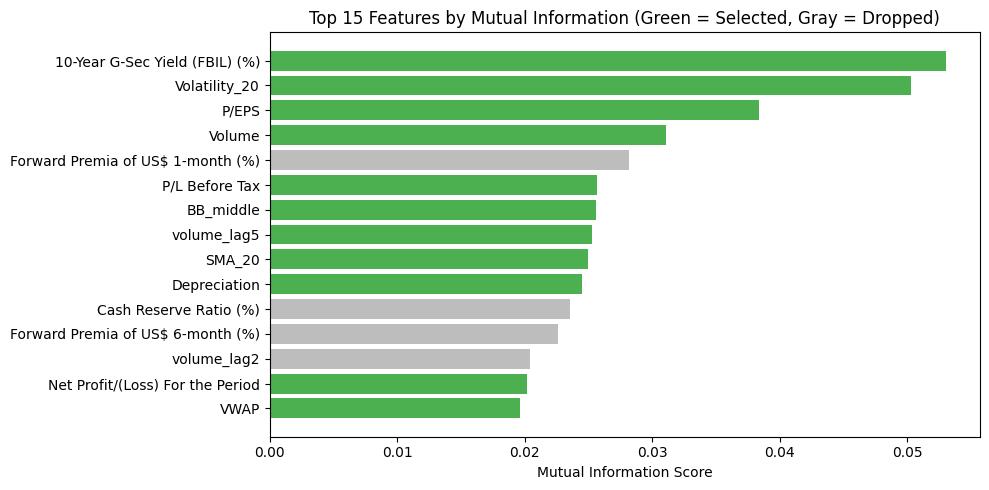

Creating interactions from top 6: ['Volatility_20', 'Volume', 'volume_lag5', 'SMA_20', 'BB_middle', 'VWAP']
✅ Added 15 interaction features
   Total features for modeling: 45
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 45), Val shape: (64, 45), Test shape: (61, 45)
Train target distribution: target
0    0.514397
1    0.485603
Name: proportion, dtype: float64
Val target distribution: target
0    0.546875
1    0.453125
Name: proportion, dtype: float64
Test target distribution: target
1    0.606557
0    0.393443
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'Net Sales/Income from operations', 'USDINR_ret', 'CRUDE_ret', 'Bank Rate (%)', '10-Year G-Sec Yield (FBIL) (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Bu

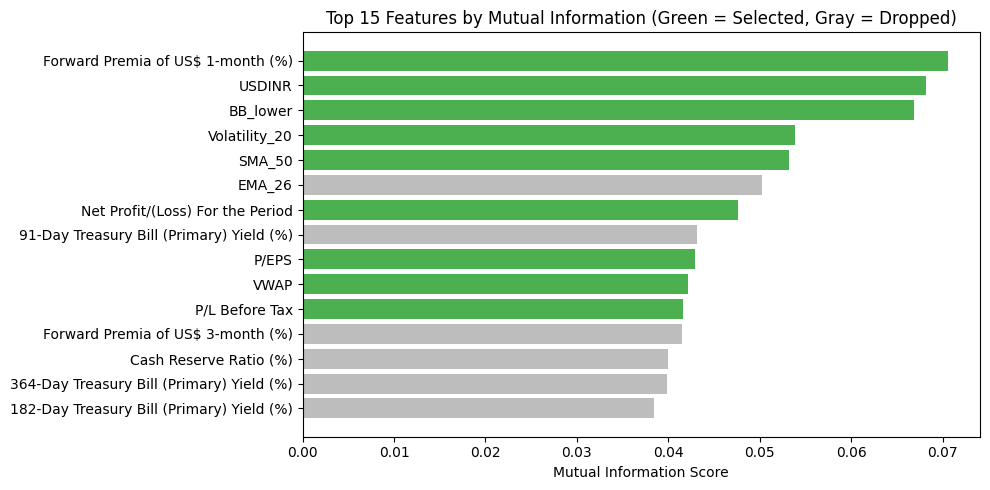

Creating interactions from top 6: ['USDINR', 'BB_lower', 'Volatility_20', 'SMA_50', 'VWAP', 'Basic EPS']
✅ Added 15 interaction features
   Total features for modeling: 43
Before rolling standardization: (1420, 91)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 43), Val shape: (64, 43), Test shape: (61, 43)
Train target distribution: target
0    0.522957
1    0.477043
Name: proportion, dtype: float64
Val target distribution: target
1    0.5625
0    0.4375
Name: proportion, dtype: float64
Test target distribution: target
0    0.606557
1    0.393443
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'USDINR', 'CRUDE', 'Forward Premia of US$ 1-month (%)', 'Bank Rate (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return_lag1', 'Buying_Pressure', 'Selling_Pressure', 'SMA_50', 'M

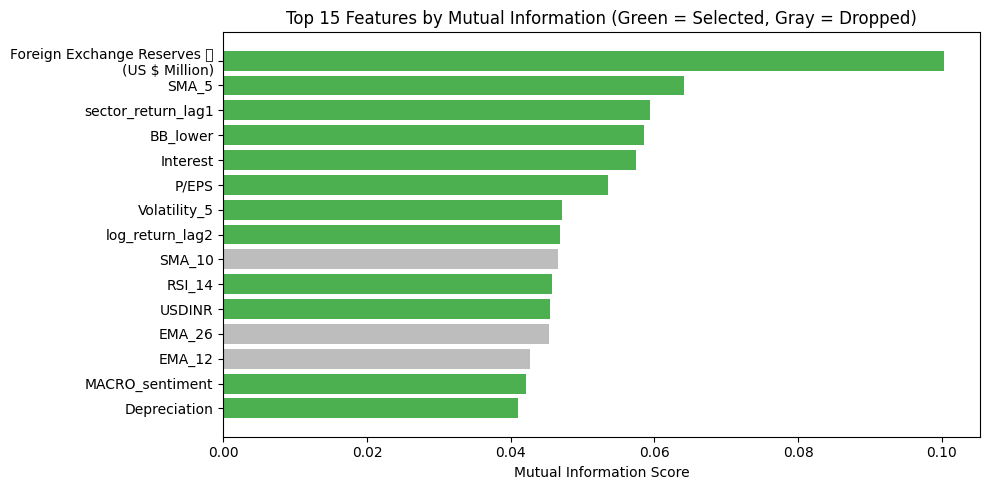

Creating interactions from top 6: ['Foreign Exchange Reserves \r\n(US $ Million)', 'SMA_5', 'sector_return_lag1', 'BB_lower', 'Volatility_5', 'log_return_lag2']
✅ Added 15 interaction features
   Total features for modeling: 41
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 41), Val shape: (64, 41), Test shape: (61, 41)
Train target distribution: target
1    0.50428
0    0.49572
Name: proportion, dtype: float64
Val target distribution: target
1    0.515625
0    0.484375
Name: proportion, dtype: float64
Test target distribution: target
1    0.508197
0    0.491803
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'CRUDE', 'Forward Premia of US$ 6-month (%)', 'Base Rate (%)', 'Foreign Exchange Reserves 

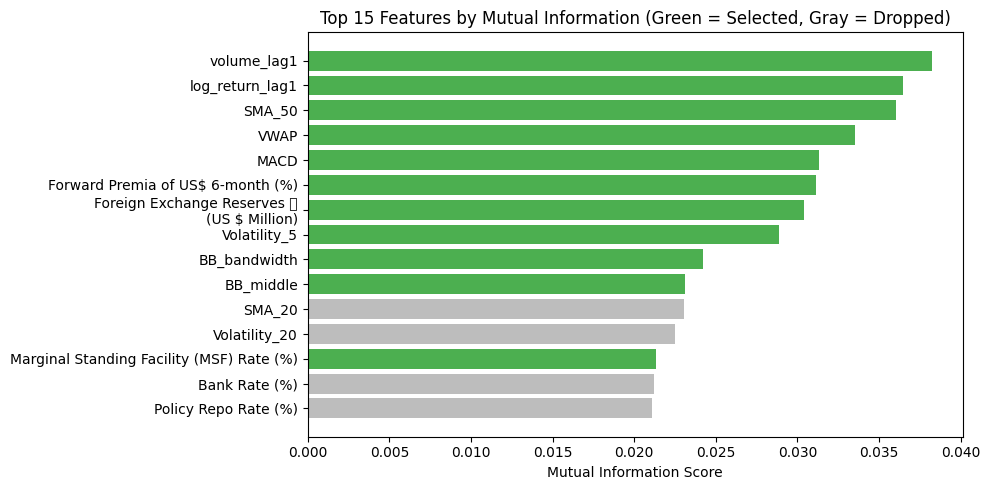

Creating interactions from top 6: ['volume_lag1', 'log_return_lag1', 'SMA_50', 'VWAP', 'MACD', 'Foreign Exchange Reserves \r\n(US $ Million)']
✅ Added 15 interaction features
   Total features for modeling: 46
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 46), Val shape: (64, 46), Test shape: (61, 46)
Train target distribution: target
0    0.503502
1    0.496498
Name: proportion, dtype: float64
Val target distribution: target
1    0.53125
0    0.46875
Name: proportion, dtype: float64
Test target distribution: target
0    0.508197
1    0.491803
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'CRUDE', 'Forward Premia of US$ 6-month (%)', 'Marginal Standing Facility (MSF) Rate (%)', 'Foreign Exchange

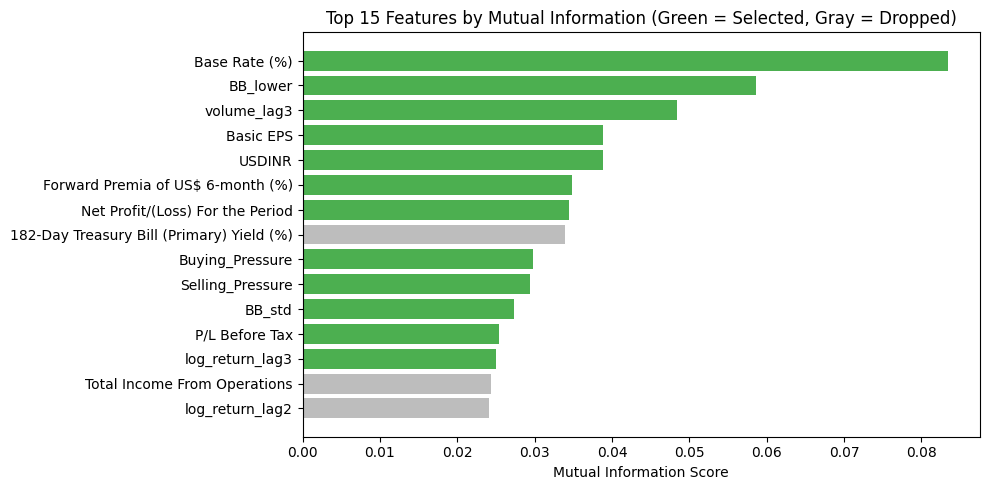

Creating interactions from top 6: ['BB_lower', 'volume_lag3', 'Basic EPS', 'USDINR', 'Buying_Pressure', 'Selling_Pressure']
✅ Added 15 interaction features
   Total features for modeling: 43
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 43), Val shape: (64, 43), Test shape: (61, 43)
Train target distribution: target
0    0.508949
1    0.491051
Name: proportion, dtype: float64
Val target distribution: target
1    0.515625
0    0.484375
Name: proportion, dtype: float64
Test target distribution: target
0    0.540984
1    0.459016
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'CRUDE', 'Forward Premia of US$ 6-month (%)', 'Base Rate (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_return

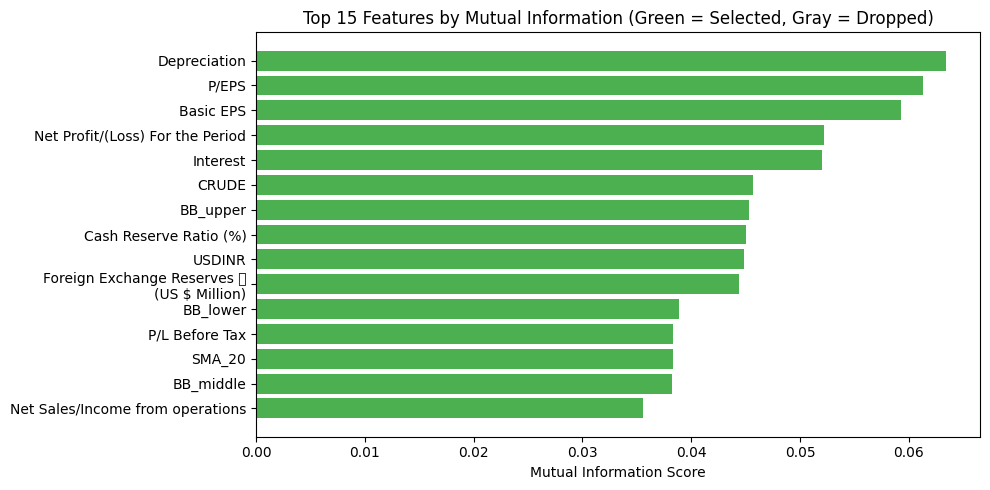

Creating interactions from top 6: ['Basic EPS', 'CRUDE', 'BB_upper', 'USDINR', 'Foreign Exchange Reserves \r\n(US $ Million)', 'BB_lower']
✅ Added 15 interaction features
   Total features for modeling: 41
Before rolling standardization: (1420, 95)
✅ Rolling standardization complete. Final rows: 1410
Train shape: (1285, 41), Val shape: (64, 41), Test shape: (61, 41)
Train target distribution: target
1    0.519844
0    0.480156
Name: proportion, dtype: float64
Val target distribution: target
1    0.53125
0    0.46875
Name: proportion, dtype: float64
Test target distribution: target
1    0.639344
0    0.360656
Name: proportion, dtype: float64
Train dates: 2020-03-26 00:00:00 to 2025-06-30 00:00:00
Val dates: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test dates: 2025-10-01 00:00:00 to 2025-12-30 00:00:00
X_train columns: ['Volume', 'Net Sales/Income from operations', 'USDINR', 'CRUDE', 'Base Rate (%)', 'Cash Reserve Ratio (%)', 'Foreign Exchange Reserves \r\n(US $ Million)', 'sector_retu

In [41]:
stocks = {
    "RELIANCE": reliance_ml_data,
    "HDFC": HDFC_ml_data,
    "MM": MM_ml_data,
    "INFY": INFY_ml_data,
    "HUL": HUL_ml_data,
    "BHARTI": BHARTIARTL_ml_data
}

results_summary = []

for name, data in stocks.items():

    prepared = prepare_stock_dataframe(data, name, target_type="residual")

    r2, acc, _, _, _, _, _, _ = train_stock_model(prepared, name)

    results_summary.append({
        "Stock": name,
        "R2": r2,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results_summary)
print("\nFINAL SUMMARY")
print(results_df)